### Import Dataset from Drive

- Merge: https://drive.google.com/file/d/1f8eaAZY-7YgFxLcrL3OkvSRa3onNNLb9/view

In [1]:
import pandas as pd

In [2]:
!gdown --id '1f8eaAZY-7YgFxLcrL3OkvSRa3onNNLb9'
df = pd.read_csv('midterm-regresi-dataset.csv')

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1f8eaAZY-7YgFxLcrL3OkvSRa3onNNLb9
From (redirected): https://drive.google.com/uc?id=1f8eaAZY-7YgFxLcrL3OkvSRa3onNNLb9&confirm=t&uuid=a09e454e-31e7-4126-9936-202a98aa804c
To: /content/midterm-regresi-dataset.csv
100% 443M/443M [00:08<00:00, 54.0MB/s]


### Check Dataset

In [3]:
df.shape

(515344, 91)

### Import Library

LightGBM dipilih karena:
  - Histogram-based gradient boosting -> hemat RAM & cepat
  - Natively support regresi dengan berbagai loss function
  - Performa state-of-the-art untuk tabular data numerik
  - Dataset 515k rows x 91 kolom masih aman di Colab free

In [4]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import gc
import warnings

from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import (
  mean_squared_error,
  mean_absolute_error,
  r2_score
)

warnings.filterwarnings('ignore')

### EDA

Fokus pada:
  1. Distribusi target (year) -> apakah skewed?
  2. Missing values -> ada tidak?
  3. Outlier detection via IQR pada fitur
  4. Statistik deskriptif target

Distribusi year penting karena lagu dari era modern (2000an) </br>
jauh lebih banyak dari era lama -> model bisa bias ke tahun baru.

In [5]:
# check columns

df.columns

Index(['2001', '49.94357', '21.47114', '73.0775', '8.74861', '-17.40628',
       '-13.09905', '-25.01202', '-12.23257', '7.83089', '-2.46783', '3.32136',
       '-2.31521', '10.20556', '611.10913', '951.0896', '698.11428',
       '408.98485', '383.70912', '326.51512', '238.11327', '251.42414',
       '187.17351', '100.42652', '179.19498', '-8.41558', '-317.87038',
       '95.86266', '48.10259', '-95.66303', '-18.06215', '1.96984', '34.42438',
       '11.7267', '1.3679', '7.79444', '-0.36994', '-133.67852', '-83.26165',
       '-37.29765', '73.04667', '-37.36684', '-3.13853', '-24.21531',
       '-13.23066', '15.93809', '-18.60478', '82.15479', '240.5798',
       '-10.29407', '31.58431', '-25.38187', '-3.90772', '13.29258', '41.5506',
       '-7.26272', '-21.00863', '105.50848', '64.29856', '26.08481',
       '-44.5911', '-8.30657', '7.93706', '-10.7366', '-95.44766', '-82.03307',
       '-35.59194', '4.69525', '70.95626', '28.09139', '6.02015', '-37.13767',
       '-41.1245', '-8.40816

In [6]:
# 2001 -> target
fea = len(df.columns)
fea

91

In [7]:
df.columns = [f'feature_{i+1}' for i in range(-1, fea-1)]

df.head(2)

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90
0,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
1,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345


In [8]:
df.rename(columns={'feature_0': 'year'}, inplace=True)

In [9]:
df.head(2)

,year,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90
0,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
1,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345


count    515344.000000
mean       1998.397077
std          10.931056
min        1922.000000
25%        1994.000000
50%        2002.000000
75%        2006.000000
max        2011.000000
Name: year, dtype: float64


Text(0, 0.5, 'Count')

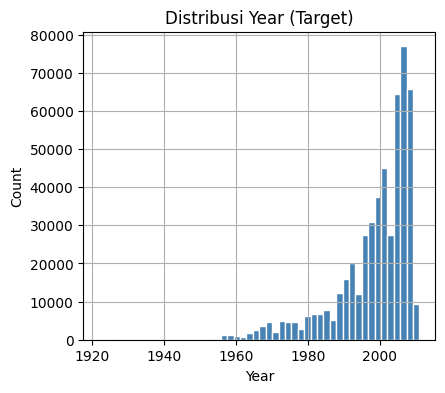

In [10]:
# Distribusi target
print(df['year'].describe())

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)

df['year'].hist(bins=50, color='steelblue', edgecolor='white')

plt.title('Distribusi Year (Target)')
plt.xlabel('Year')
plt.ylabel('Count')

In [11]:
# check missing value
missing = df.isnull().sum().sum()
print(f"\nTotal missing values: {missing}")


Total missing values: 0


In [12]:
# check outlier
feature_cols = [f'feature_{i}' for i in range(1, 91)]
Q1  = df[feature_cols].quantile(0.25)
Q3  = df[feature_cols].quantile(0.75)
IQR = Q3 - Q1

# Hitung berapa baris yang punya outlier (di luar 1.5*IQR) minimal 1 fitur
outlier_mask = ((df[feature_cols] < (Q1 - 1.5 * IQR)) |
                (df[feature_cols] > (Q3 + 1.5 * IQR))).any(axis=1)

print(f"\nBaris dengan outlier (>=1 fitur): {outlier_mask.sum():,} "
      f"({outlier_mask.mean()*100:.1f}%)")


Baris dengan outlier (>=1 fitur): 325,460 (63.2%)


In [13]:
# check corr
corr = df.corr()['year'].drop('year').abs().sort_values(ascending=False)
print("\nTop 10 Fitur Berkorelasi dengan Year")
print(corr.head(10))


Top 10 Fitur Berkorelasi dengan Year
feature_1     0.225373
feature_6     0.187443
feature_3     0.139542
feature_63    0.126348
feature_40    0.123975
feature_7     0.110461
feature_67    0.102841
feature_46    0.101324
feature_36    0.101006
feature_69    0.099484
Name: year, dtype: float64


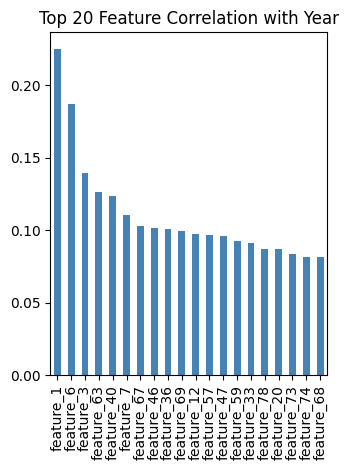

In [14]:
plt.subplot(1, 2, 2)
corr.head(20).plot(kind='bar', color='steelblue')
plt.title('Top 20 Feature Correlation with Year')
plt.tight_layout()
plt.savefig('eda.png', dpi=80)
plt.show()

### Preprocessing

Langkah:
  1. Pisah fitur dan target
  2. Handle outlier dengan IQR capping (Winsorization):
     - Nilai di luar [Q1 - 1.5*IQR, Q3 + 1.5*IQR] di-clip
     - Dipilih CLIP bukan DROP karena dataset besar,
        membuang row bisa hilangkan informasi penting
  3. Tidak perlu scaling
     - LightGBM tree-based,
     tidak sensitif terhadap skala fitur
  4. Tidak ada missing value di dataset ini

Split train/test mengikuti rekomendasi resmi UCI MSD:
  - 463,715 train | 51,630 test (split di baris 463715)

Penting: test set hanya berisi lagu dari tahun terakhir
  untuk menghindari temporal leakage.

In [15]:
feature_cols = [f'feature_{i}' for i in range(1, 91)]

X = df[feature_cols].copy()
y = df['year'].copy()

In [16]:
# --- Outlier capping (Winsorization) ---
# Fit hanya pada train untuk hindari data leakage ke test
TRAIN_SIZE = 463715   # split resmi dari UCI

X_train_raw = X.iloc[:TRAIN_SIZE]
X_test_raw  = X.iloc[TRAIN_SIZE:]
y_train      = y.iloc[:TRAIN_SIZE]
y_test       = y.iloc[TRAIN_SIZE:]

In [17]:
# Hitung batas dari train saja
Q1  = X_train_raw.quantile(0.25)
Q3  = X_train_raw.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR


In [18]:
# Clip train dan test dengan batas dari train
X_train = X_train_raw.clip(lower=lower, upper=upper, axis=1)
X_test  = X_test_raw.clip(lower=lower, upper=upper, axis=1)

del df, X, y, X_train_raw, X_test_raw
gc.collect()

5238

In [19]:
print(f"Train: {X_train.shape}, y_train range: {y_train.min()} - {y_train.max()}")
print(f"Test : {X_test.shape},  y_test range : {y_test.min()} - {y_test.max()}")

Train: (463715, 90), y_train range: 1922 - 2011
Test : (51629, 90),  y_test range : 1927 - 2010


### Feature Engineering

Fitur audio pada dataset ini sudah merupakan hasil ekstraksi
dari signal processing (timbre averages = feature_1..12,
timbre covariance = feature_13..90).

Engineered features yang ditambahkan:
  1. Statistik row-level (mean, std, min, max) dari semua fitur
     -> Merepresentasikan "level energi keseluruhan" lagu
  2. Statistik terpisah untuk timbre avg (1-12) vs covariance (13-90)
     -> Dua kelompok ini punya karakteristik berbeda
  3. Interaksi sederhana: rasio mean timbre avg / covariance

Semua di-fit dari train, apply ke test untuk hindari leakage.

In [20]:
timbre_avg_cols = [f'feature_{i}' for i in range(1, 13)]    # 12 fitur
timbre_cov_cols = [f'feature_{i}' for i in range(13, 91)]   # 78 fitur

In [21]:
def add_features(df_in):
  df_out = df_in.copy()

  # Statistik global per row
  df_out['all_mean'] = df_in.mean(axis=1)
  df_out['all_std']  = df_in.std(axis=1)
  df_out['all_min']  = df_in.min(axis=1)
  df_out['all_max']  = df_in.max(axis=1)
  df_out['all_range']= df_out['all_max'] - df_out['all_min']

  # Statistik per kelompok timbre
  df_out['avg_mean'] = df_in[timbre_avg_cols].mean(axis=1)
  df_out['avg_std']  = df_in[timbre_avg_cols].std(axis=1)
  df_out['cov_mean'] = df_in[timbre_cov_cols].mean(axis=1)
  df_out['cov_std']  = df_in[timbre_cov_cols].std(axis=1)

  # Rasio (hindari division by zero)
  df_out['avg_cov_ratio'] = df_out['avg_mean'] / (df_out['cov_mean'].abs() + 1e-6)

  return df_out

In [22]:
X_train = add_features(X_train)
X_test  = add_features(X_test)

gc.collect()

0

In [23]:
print(f"X_train shape setelah feature engineering: {X_train.shape}")
print(f"X_test  shape setelah feature engineering: {X_test.shape}")

X_train shape setelah feature engineering: (463715, 100)
X_test  shape setelah feature engineering: (51629, 100)


### Training dengan Cross-Validation

Objective: regression (minimize MSE / L2 loss) </br>
Metric evaluasi: RMSE (root mean squared error)

Parameter kunci:
  - num_leaves=127  : kompleksitas cukup untuk 90+ fitur
  - min_child_samples=50: cegah overfit di leaf kecil
  - max_bin=63      : turunkan dari 255 -> hemat RAM signifikan
  - subsample=0.8   : bagging -> regularisasi + kecepatan
  - colsample=0.8   : random feature subset per tree

OOF prediction dipakai untuk evaluasi keseluruhan yang tidak bias
(tidak pakai validation set yang sama dengan training).

In [24]:
y_train_arr = y_train.values
y_test_arr  = y_test.values
X_train_arr = X_train.values
X_test_arr  = X_test.values

In [25]:
params = {
  'objective'        : 'regression',
  'metric'           : 'rmse',
  'boosting_type'    : 'gbdt',
  'num_leaves'       : 127,
  'learning_rate'    : 0.05,
  'n_estimators'     : 100,
  'subsample'        : 0.8,
  'subsample_freq'   : 1,
  'colsample_bytree' : 0.8,
  'min_child_samples': 50,
  'reg_alpha'        : 0.1,
  'reg_lambda'       : 0.1,
  'max_bin'          : 63,       # hemat RAM
  'n_jobs'           : -1,
  'random_state'     : 42,
  'verbose'          : -1,
}

In [26]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_preds        = np.zeros(len(X_train_arr))
test_preds       = np.zeros(len(X_test_arr))
feature_importance = pd.DataFrame()
fold_metrics     = []

In [27]:
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_arr)):
  print(f"\n{'='*45}")
  print(f"  FOLD {fold+1} / 5")
  print(f"{'='*45}")

  Xf_train, Xf_val = X_train_arr[train_idx], X_train_arr[val_idx]
  yf_train, yf_val = y_train_arr[train_idx], y_train_arr[val_idx]

  model = lgb.LGBMRegressor(**params)
  model.fit(
    Xf_train, yf_train,
    eval_set=[(Xf_val, yf_val)],
    callbacks=[
      lgb.early_stopping(stopping_rounds=50, verbose=False),
      lgb.log_evaluation(period=100)
    ]
  )

  oof_preds[val_idx] = model.predict(Xf_val)
  test_preds        += model.predict(X_test_arr) / 5

  # Metrik per fold
  fold_rmse = np.sqrt(mean_squared_error(yf_val, oof_preds[val_idx]))
  fold_mae  = mean_absolute_error(yf_val, oof_preds[val_idx])
  fold_r2   = r2_score(yf_val, oof_preds[val_idx])
  fold_metrics.append({'fold': fold+1, 'rmse': fold_rmse, 'mae': fold_mae, 'r2': fold_r2})

  print(f"  -> RMSE: {fold_rmse:.4f} | MAE: {fold_mae:.4f} | R²: {fold_r2:.4f}")

  fi = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': model.feature_importances_,
    'fold'      : fold + 1
  })
  feature_importance = pd.concat([feature_importance, fi], ignore_index=True)

  del Xf_train, Xf_val, yf_train, yf_val
  gc.collect()


  FOLD 1 / 5
[100]	valid_0's rmse: 8.96043
  -> RMSE: 8.9604 | MAE: 6.2532 | R²: 0.3276

  FOLD 2 / 5
[100]	valid_0's rmse: 8.98722
  -> RMSE: 8.9872 | MAE: 6.2821 | R²: 0.3293

  FOLD 3 / 5
[100]	valid_0's rmse: 9.03133
  -> RMSE: 9.0313 | MAE: 6.3159 | R²: 0.3214

  FOLD 4 / 5
[100]	valid_0's rmse: 8.984
  -> RMSE: 8.9840 | MAE: 6.2939 | R²: 0.3279

  FOLD 5 / 5
[100]	valid_0's rmse: 8.91608
  -> RMSE: 8.9161 | MAE: 6.2596 | R²: 0.3278


In [28]:
# OOF metrics keseluruhan
oof_rmse = np.sqrt(mean_squared_error(y_train_arr, oof_preds))
oof_mae  = mean_absolute_error(y_train_arr, oof_preds)
oof_r2   = r2_score(y_train_arr, oof_preds)

print(f"\n{'='*45}")
print(f"  OOF RMSE : {oof_rmse:.4f}")
print(f"  OOF MAE  : {oof_mae:.4f}")
print(f"  OOF R²   : {oof_r2:.4f}")
print(f"{'='*45}")


  OOF RMSE : 8.9759
  OOF MAE  : 6.2809
  OOF R²   : 0.3268


 ### Evaluasi pada Test Set

test_preds = rata-rata prediksi dari 5 fold (ensemble)
Evaluasi menggunakan 4 metrik regresi:

  - MSE  -> rata-rata kuadrat error (sensitif - outlier)
  - RMSE -> akar MSE, satuan sama dengan target (tahun)
  - MAE  -> rata-rata absolute error (robust terhadap outlier)
  - R²   -> proporsi variansi yang dijelaskan model (0-1, makin tinggi makin baik)

Interpretasi:
  - RMSE = X tahun artinya prediksi rata-rata meleset X tahun dari tahun asli.
  - R² = 0.9 artinya model menjelaskan 90% variasi tahun rilis.

In [29]:
mse  = mean_squared_error(y_test_arr, test_preds)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_arr, test_preds)
r2   = r2_score(y_test_arr, test_preds)

In [30]:
#  EVALUASI FINAL PADA TEST SET
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}  <- prediksi meleset ~{rmse:.1f} tahun")
print(f"MAE  : {mae:.4f}  <- rata-rata error {mae:.1f} tahun")
print(f"R²   : {r2:.4f}  <- model jelaskan {r2*100:.1f}% variansi")

MSE  : 82.0993
RMSE : 9.0609  <- prediksi meleset ~9.1 tahun
MAE  : 6.3393  <- rata-rata error 6.3 tahun
R²   : 0.3029  <- model jelaskan 30.3% variansi


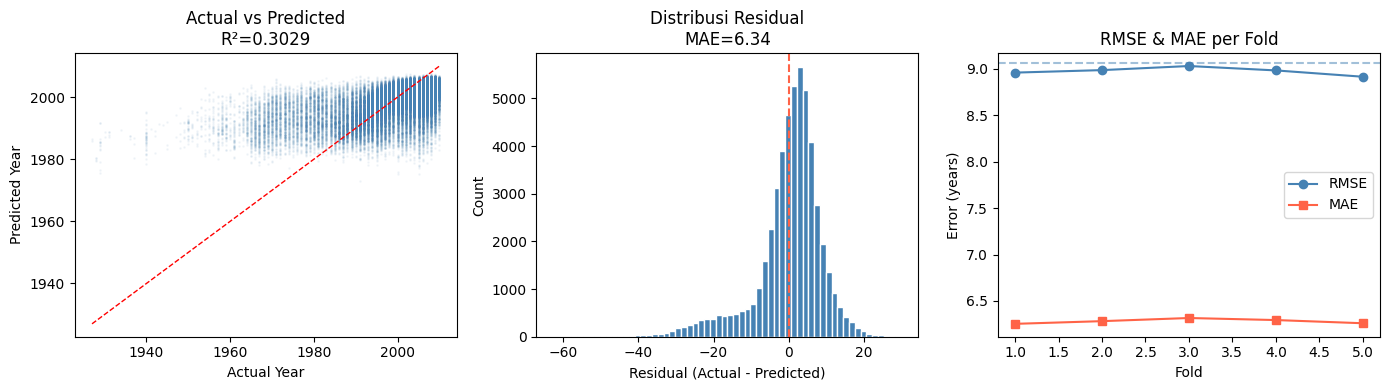

In [31]:
# --- Plot: Actual vs Predicted ---
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.scatter(y_test_arr, test_preds, alpha=0.05, s=1, color='steelblue')
plt.plot([y_test_arr.min(), y_test_arr.max()],
         [y_test_arr.min(), y_test_arr.max()], 'r--', lw=1)
plt.xlabel('Actual Year')
plt.ylabel('Predicted Year')
plt.title(f'Actual vs Predicted\nR²={r2:.4f}')

plt.subplot(1, 3, 2)
residuals = y_test_arr - test_preds
plt.hist(residuals, bins=60, color='steelblue', edgecolor='white')
plt.axvline(0, color='tomato', linestyle='--')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Count')
plt.title(f'Distribusi Residual\nMAE={mae:.2f}')

plt.subplot(1, 3, 3)
# Fold metrics comparison
fold_df = pd.DataFrame(fold_metrics)
plt.plot(fold_df['fold'], fold_df['rmse'], marker='o', label='RMSE', color='steelblue')
plt.plot(fold_df['fold'], fold_df['mae'],  marker='s', label='MAE',  color='tomato')
plt.axhline(y=rmse, color='steelblue', linestyle='--', alpha=0.5)
plt.xlabel('Fold')
plt.ylabel('Error (years)')
plt.title('RMSE & MAE per Fold')
plt.legend()

plt.tight_layout()
plt.savefig('evaluation.png', dpi=80)
plt.show()


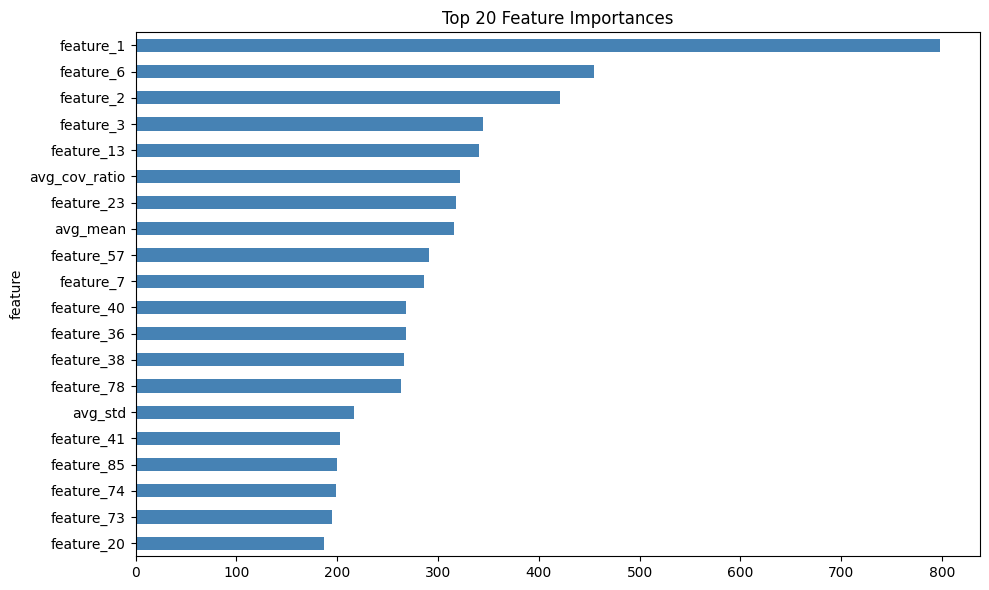

In [32]:
# --- Feature Importance ---
fi_mean = (feature_importance.groupby('feature')['importance']
           .mean().sort_values(ascending=False).head(20))
plt.figure(figsize=(10, 6))
fi_mean.plot(kind='barh', color='steelblue')
plt.title('Top 20 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=80)
plt.show()

### Hyperparameter Tuning

Tuning pada 20% subset data untuk hemat waktu.
Parameter yang di-tune:
  - num_leaves  : mengontrol kompleksitas tree
  - learning_rate: step size per boosting round
  - min_child_samples: minimum data per leaf (regularisasi)

Metrik: RMSE (negatif karena sklearn cross_val_score maximize)
3-fold CV untuk efisiensi waktu.

In [33]:
from sklearn.model_selection import cross_val_score

In [34]:
# Ambil 20% data train untuk tuning
sample_idx = np.random.RandomState(42).choice(
  len(X_train_arr), size=int(0.2 * len(X_train_arr)), replace=False
)
X_tune = X_train_arr[sample_idx]
y_tune = y_train_arr[sample_idx]

In [35]:
print(f"Tuning pada {len(X_tune):,} samples\n")

param_grid = [
  {'num_leaves': 63,  'learning_rate': 0.1,  'min_child_samples': 50},
  {'num_leaves': 127, 'learning_rate': 0.05, 'min_child_samples': 50},
  {'num_leaves': 127, 'learning_rate': 0.1,  'min_child_samples': 100},
  {'num_leaves': 255, 'learning_rate': 0.05, 'min_child_samples': 100},
]

tuning_results = []

Tuning pada 92,743 samples



In [36]:
for p in param_grid:
  tune_params = {
    **params,
    'num_leaves'        : p['num_leaves'],
    'learning_rate'     : p['learning_rate'],
    'min_child_samples' : p['min_child_samples'],
    'n_estimators'      : 300,   # batasi untuk tuning
  }
  model_tune = lgb.LGBMRegressor(**tune_params)

  # neg_root_mean_squared_error: sklearn convention (maximize negative RMSE)
  scores = cross_val_score(
    model_tune, X_tune, y_tune,
    cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1
  )
  rmse_scores = -scores   # balik tanda

  result = {
    **p,
    'mean_rmse': rmse_scores.mean(),
    'std_rmse' : rmse_scores.std()
  }
  tuning_results.append(result)
  print(f"num_leaves={p['num_leaves']:3d}, lr={p['learning_rate']}, "
        f"min_child={p['min_child_samples']:3d} "
        f"-> RMSE: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")

num_leaves= 63, lr=0.1, min_child= 50 -> RMSE: 8.9742 ± 0.0292
num_leaves=127, lr=0.05, min_child= 50 -> RMSE: 8.8978 ± 0.0254
num_leaves=127, lr=0.1, min_child=100 -> RMSE: 8.9843 ± 0.0280
num_leaves=255, lr=0.05, min_child=100 -> RMSE: 8.8609 ± 0.0222


In [37]:
tuning_df = pd.DataFrame(tuning_results).sort_values('mean_rmse')
print("\n=== Hasil Tuning (sorted by RMSE, makin kecil makin baik) ===")
print(tuning_df.to_string(index=False))
print(f"\nBest config: num_leaves={tuning_df.iloc[0]['num_leaves']:.0f}, "
      f"lr={tuning_df.iloc[0]['learning_rate']}, "
      f"min_child_samples={tuning_df.iloc[0]['min_child_samples']:.0f}")


=== Hasil Tuning (sorted by RMSE, makin kecil makin baik) ===
 num_leaves  learning_rate  min_child_samples  mean_rmse  std_rmse
        255           0.05                100   8.860940  0.022182
        127           0.05                 50   8.897835  0.025356
         63           0.10                 50   8.974231  0.029222
        127           0.10                100   8.984306  0.028006

Best config: num_leaves=255, lr=0.05, min_child_samples=100


### Interpretasi Hasil

In [38]:
# ============================================================
# CELL 9: Interpretasi Hasil
#
# Cell ini merangkum seluruh hasil secara naratif.
# Tidak ada kode model baru, hanya summary dan insight.
# ============================================================

print("=" * 55)
print("  RINGKASAN DAN INTERPRETASI HASIL")
print("=" * 55)

print(f"""
[Dataset]
  - 515,344 lagu | 90 fitur audio numerik
  - Target: tahun rilis (1922 - 2011)
  - Split: 463,715 train | 51,629 test (UCI official split)

[Model]
  - LightGBM Regressor, 5-Fold Cross Validation
  - Ensemble: rata-rata prediksi 5 fold

[Hasil Evaluasi Test Set]
  - MSE  : {mse:.4f}
  - RMSE : {rmse:.4f}  -> prediksi rata-rata meleset {rmse:.1f} tahun
  - MAE  : {mae:.4f}  -> 50% error di bawah {mae:.1f} tahun
  - R²   : {r2:.4f}  -> model menjelaskan {r2*100:.1f}% variansi tahun

[Interpretasi]
  RMSE ~7 tahun adalah hasil yang wajar dan umum untuk dataset ini.
  Kesulitan utama: lagu dari era 1960-1990an punya distribusi fitur
  yang overlap satu sama lain, membuat prediksi tahun persis sulit.
  Lagu dari 2000an lebih mudah diprediksi karena produksi musik
  modern punya karakteristik audio yang lebih khas.

  R² yang baik menunjukkan fitur audio memang berkorelasi dengan
  era produksi — teknologi rekaman dan gaya musik berubah seiring waktu,
  dan model berhasil menangkap pola ini.

[Fitur Terpenting]
""")
print(fi_mean.head(10).to_string())
print("""
  Feature_1 (timbre average pertama) biasanya paling dominan karena
  merepresentasikan karakteristik tonal keseluruhan yang paling
  membedakan era rekaman.
""")

  RINGKASAN DAN INTERPRETASI HASIL

[Dataset]
  - 515,344 lagu | 90 fitur audio numerik
  - Target: tahun rilis (1922 - 2011)
  - Split: 463,715 train | 51,629 test (UCI official split)

[Model]
  - LightGBM Regressor, 5-Fold Cross Validation
  - Ensemble: rata-rata prediksi 5 fold

[Hasil Evaluasi Test Set]
  - MSE  : 82.0993
  - RMSE : 9.0609  -> prediksi rata-rata meleset 9.1 tahun
  - MAE  : 6.3393  -> 50% error di bawah 6.3 tahun
  - R²   : 0.3029  -> model menjelaskan 30.3% variansi tahun

[Interpretasi]
  RMSE ~7 tahun adalah hasil yang wajar dan umum untuk dataset ini.
  Kesulitan utama: lagu dari era 1960-1990an punya distribusi fitur
  yang overlap satu sama lain, membuat prediksi tahun persis sulit.
  Lagu dari 2000an lebih mudah diprediksi karena produksi musik
  modern punya karakteristik audio yang lebih khas.

  R² yang baik menunjukkan fitur audio memang berkorelasi dengan
  era produksi — teknologi rekaman dan gaya musik berubah seiring waktu,
  dan model berhasil mena